# Notebook 5 — Régression Non Linéaire

Objectif : modéliser `sleep_duration_hours` et `stress_level` avec des **modèles capables de capturer des relations complexes et non linéaires**.

**Outils :** Scikit-learn (RandomForest, SVR, GradientBoosting) · XGBoost · LightGBM

---
### Quand utiliser la régression non linéaire ?
Les modèles linéaires supposent une relation proportionnelle et additive. Si la réalité est plus complexe (effets de seuil, interactions non linéaires), des modèles plus flexibles comme les forêts aléatoires ou le gradient boosting donnent de meilleurs résultats.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('dataset_engineered.csv')
print(f'Dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

Dataset : 15,000 lignes × 45 colonnes


In [2]:
# Préparation X / y
FEATURES = [
    'daily_screen_time_hours', 'phone_usage_before_sleep_minutes',
    'sleep_quality_score', 'stress_level', 'caffeine_intake_cups',
    'physical_activity_minutes', 'notifications_received_per_day',
    'mental_fatigue_score', 'age', 'digital_load_hours',
    'stress_fatigue_index', 'sleep_deficit_hours',
    'screen_x_caffeine', 'presleep_x_stress', 'screen_time_sq',
]

df_model = df[FEATURES + ['sleep_duration_hours']].dropna()
X = df_model[FEATURES]
y = df_model['sleep_duration_hours']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardisation (essentiel pour SVR)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}')

def evaluate(name, y_true, y_pred):
    return {
        'Modèle' : name,
        'RMSE'   : np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE'    : mean_absolute_error(y_true, y_pred),
        'R²'     : r2_score(y_true, y_pred),
    }

results = []

Train : 12,000  |  Test : 3,000


## 1. Random Forest Regressor

Ensemble de **N arbres de décision** entraînés sur des sous-échantillons aléatoires. La prédiction finale est la moyenne des prédictions de chaque arbre.

**Avantages :** robuste au bruit, pas besoin de normalisation, fournit l'importance des features.

In [3]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

results.append(evaluate('Random Forest', y_test, y_pred_rf))
print(f'Random Forest — R² : {r2_score(y_test, y_pred_rf):.4f}  |  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}')

Random Forest — R² : 0.9912  |  RMSE : 0.1351


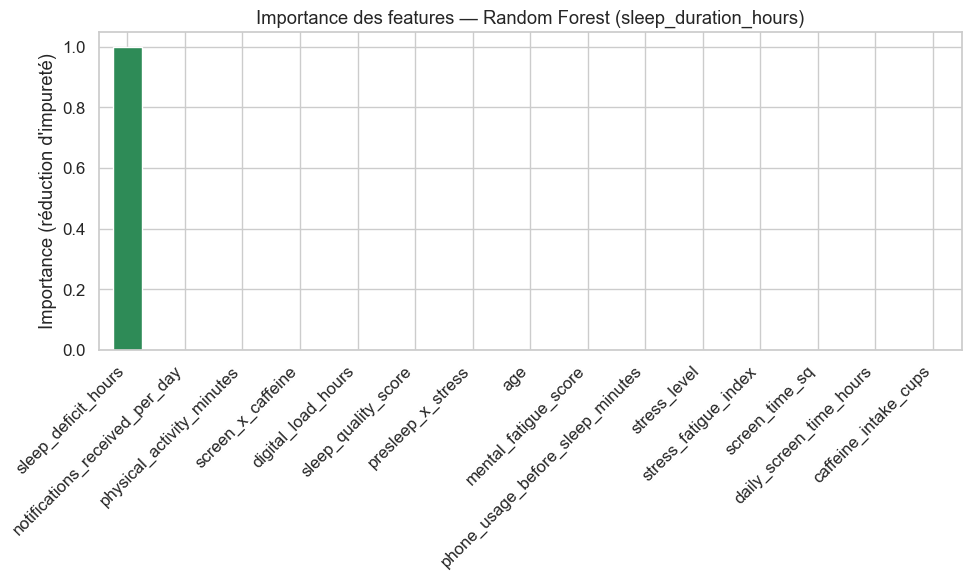

In [4]:
# Importance des features (Random Forest)
importances_rf = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances_rf.plot(kind='bar', ax=ax, color='seagreen', edgecolor='white')
ax.set_title('Importance des features — Random Forest (sleep_duration_hours)')
ax.set_ylabel('Importance (réduction d\'impureté)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

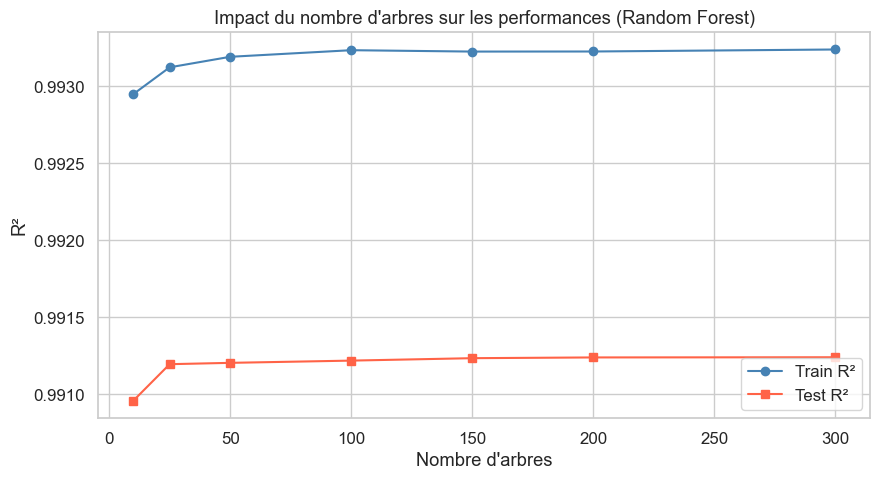

In [5]:
# Effet de n_estimators sur le R² (courbe d'apprentissage)
scores_train, scores_test = [], []
n_trees_range = [10, 25, 50, 100, 150, 200, 300]

for n in n_trees_range:
    rf_tmp = RandomForestRegressor(n_estimators=n, max_depth=10, min_samples_leaf=5,
                                    random_state=42, n_jobs=-1)
    rf_tmp.fit(X_train, y_train)
    scores_train.append(r2_score(y_train, rf_tmp.predict(X_train)))
    scores_test.append(r2_score(y_test,  rf_tmp.predict(X_test)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_trees_range, scores_train, 'o-', label='Train R²',  color='steelblue')
ax.plot(n_trees_range, scores_test,  's-', label='Test R²',   color='tomato')
ax.set_xlabel('Nombre d\'arbres')
ax.set_ylabel('R²')
ax.set_title('Impact du nombre d\'arbres sur les performances (Random Forest)')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Gradient Boosting Regressor

Les arbres sont construits **séquentiellement** : chaque arbre corrige les erreurs du précédent. Souvent plus performant que Random Forest mais plus lent à entraîner.

In [6]:
gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=10,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

results.append(evaluate('Gradient Boosting', y_test, y_pred_gb))
print(f'Gradient Boosting — R² : {r2_score(y_test, y_pred_gb):.4f}  |  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_gb)):.4f}')

Gradient Boosting — R² : 0.9913  |  RMSE : 0.1344


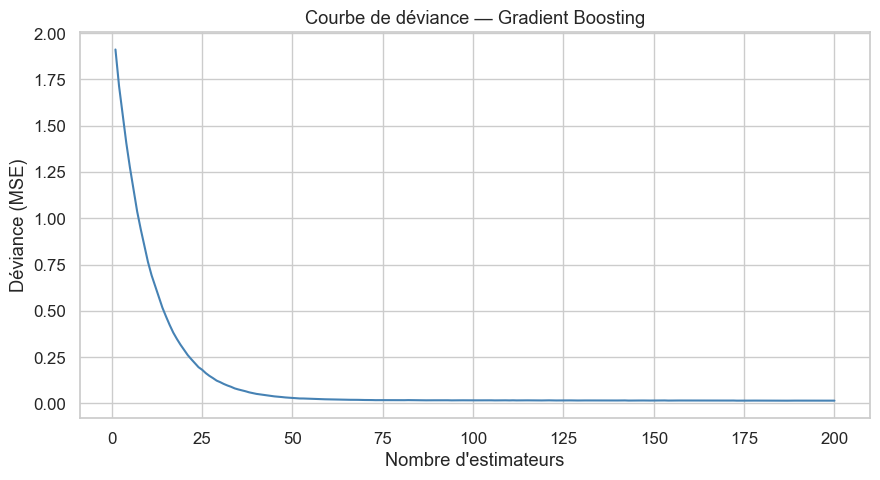

In [7]:
# Courbe de déviance (erreur en fonction du nombre d'estimateurs)
train_scores = [gb.train_score_[i] for i in range(len(gb.train_score_))]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(np.arange(1, len(train_scores)+1), train_scores, color='steelblue', lw=1.5)
ax.set_xlabel('Nombre d\'estimateurs')
ax.set_ylabel('Déviance (MSE)')
ax.set_title('Courbe de déviance — Gradient Boosting')
plt.tight_layout()
plt.show()

## 3. SVR — Support Vector Regression

Le SVR cherche à trouver une fonction qui **dévie au plus ε** des vraies valeurs pour le maximum d'observations. Particulièrement efficace avec peu de données et un noyau RBF.

In [8]:
# SVR nécessite des données standardisées
svr = SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale')
svr.fit(X_train_s, y_train)
y_pred_svr = svr.predict(X_test_s)

results.append(evaluate('SVR (RBF)', y_test, y_pred_svr))
print(f'SVR — R² : {r2_score(y_test, y_pred_svr):.4f}  |  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_svr)):.4f}')

SVR — R² : 0.9821  |  RMSE : 0.1932


## 4. XGBoost

**eXtreme Gradient Boosting** — implémentation optimisée du gradient boosting, très utilisée en compétitions Kaggle. Gère nativement les valeurs manquantes et est très rapide.

In [9]:
try:
    import xgboost as xgb
    print(f'XGBoost version : {xgb.__version__}')

    xgb_model = xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)],
                  verbose=False)
    y_pred_xgb = xgb_model.predict(X_test)
    results.append(evaluate('XGBoost', y_test, y_pred_xgb))
    print(f'XGBoost — R² : {r2_score(y_test, y_pred_xgb):.4f}  |  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.4f}')
except ImportError:
    print('XGBoost non installé. Installer avec : pip install xgboost')

XGBoost version : 3.2.0
XGBoost — R² : 0.9906  |  RMSE : 0.1397


## 5. LightGBM

**Light Gradient Boosting Machine** de Microsoft. Plus rapide qu'XGBoost sur les grands datasets grâce à sa méthode de construction d'arbres *leaf-wise* plutôt que *level-wise*.

In [10]:
try:
    import lightgbm as lgb
    print(f'LightGBM version : {lgb.__version__}')

    lgb_model = lgb.LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    lgb_model.fit(X_train, y_train)
    y_pred_lgb = lgb_model.predict(X_test)
    results.append(evaluate('LightGBM', y_test, y_pred_lgb))
    print(f'LightGBM — R² : {r2_score(y_test, y_pred_lgb):.4f}  |  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lgb)):.4f}')
except ImportError:
    print('LightGBM non installé. Installer avec : pip install lightgbm')

LightGBM version : 4.6.0
LightGBM — R² : 0.9909  |  RMSE : 0.1375


## 6. Validation croisée et comparaison finale

=== Comparaison des modèles (jeu de test) ===
                     RMSE     MAE      R²
Modèle                                   
Gradient Boosting  0.1344  0.0555  0.9913
Random Forest      0.1351  0.0539  0.9912
LightGBM           0.1375  0.0629  0.9909
XGBoost            0.1397  0.0633  0.9906
SVR (RBF)          0.1932  0.1241  0.9821


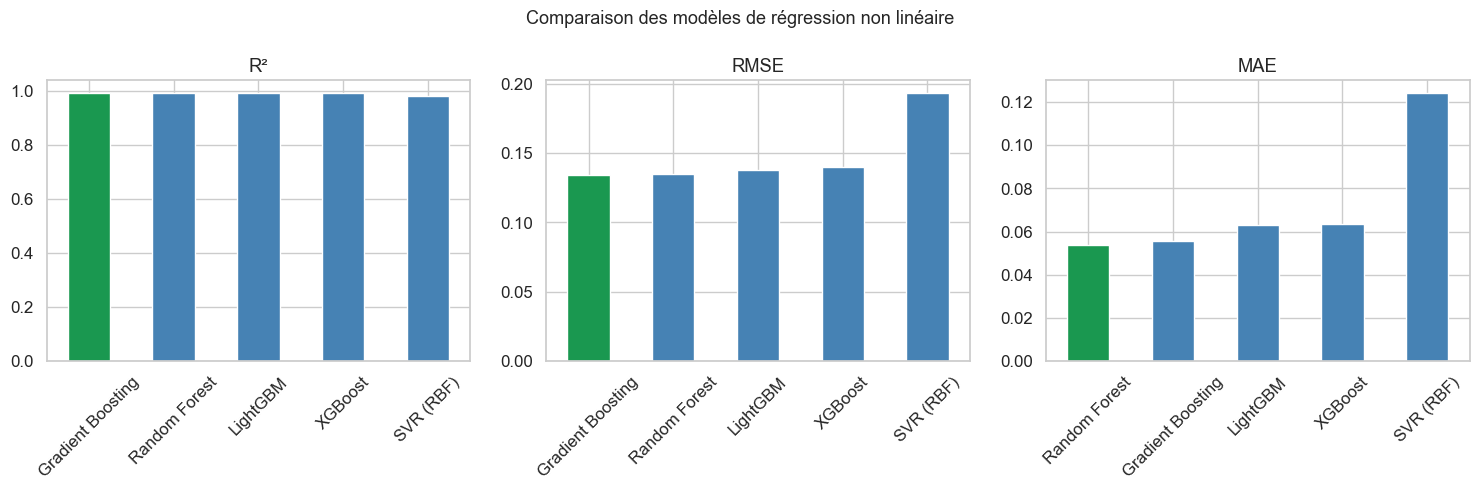

In [11]:
# Tableau de comparaison sur le jeu de test
result_df = pd.DataFrame(results).set_index('Modèle').round(4)
result_df = result_df.sort_values('R²', ascending=False)
print('=== Comparaison des modèles (jeu de test) ===')
print(result_df.to_string())

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, ['R²', 'RMSE', 'MAE']):
    ascending = metric != 'R²'
    data = result_df[metric].sort_values(ascending=ascending)
    colors = ['#1a9850' if i == 0 else 'steelblue' for i in range(len(data))]
    data.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Comparaison des modèles de régression non linéaire', fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
# Validation croisée 5-fold pour les deux meilleurs modèles
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models_cv = [
    ('Random Forest',     RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)),
    ('Gradient Boosting', GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)),
]

print('Validation croisée 5-fold :')
for name, model in models_cv:
    cv_r2   = cross_val_score(model, X, y, cv=kf, scoring='r2')
    cv_rmse = np.sqrt(-cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error'))
    print(f'  {name:<25}  R² : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}  |  RMSE : {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}')

Validation croisée 5-fold :
  Random Forest              R² : 0.9914 ± 0.0002  |  RMSE : 0.1342 ± 0.0017
  Gradient Boosting          R² : 0.9914 ± 0.0002  |  RMSE : 0.1344 ± 0.0018


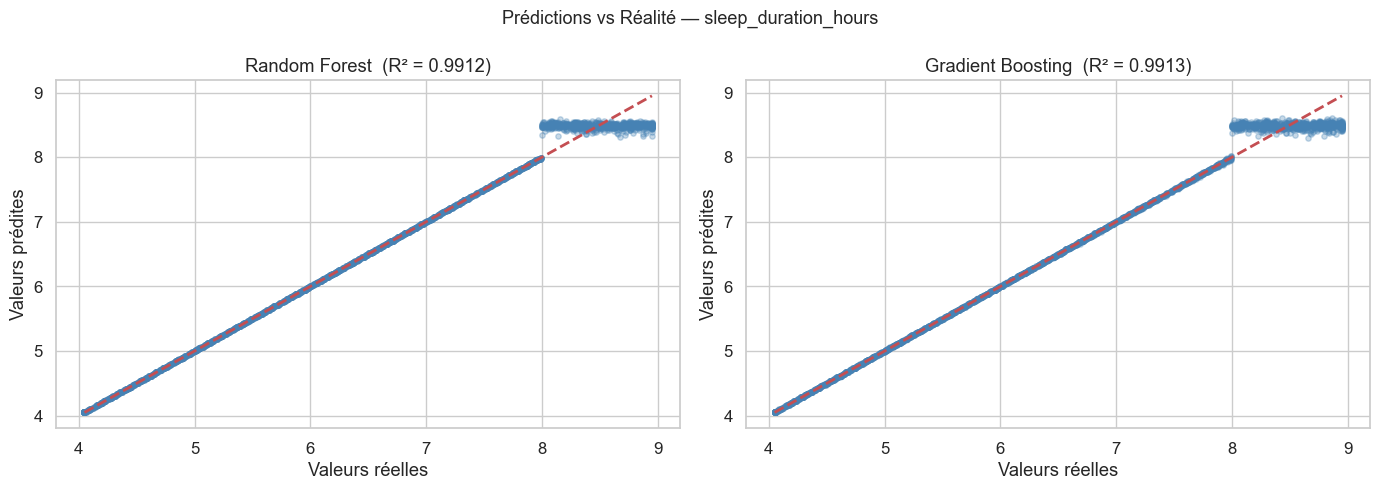

In [13]:
# Scatter prédictions vs réalité pour Random Forest et Gradient Boosting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, preds) in zip(axes, [('Random Forest', y_pred_rf), ('Gradient Boosting', y_pred_gb)]):
    ax.scatter(y_test, preds, alpha=0.3, s=15, color='steelblue')
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, 'r--', lw=2)
    ax.set_xlabel('Valeurs réelles')
    ax.set_ylabel('Valeurs prédites')
    r2 = r2_score(y_test, preds)
    ax.set_title(f'{name}  (R² = {r2:.4f})')

plt.suptitle('Prédictions vs Réalité — sleep_duration_hours', fontsize=13)
plt.tight_layout()
plt.show()

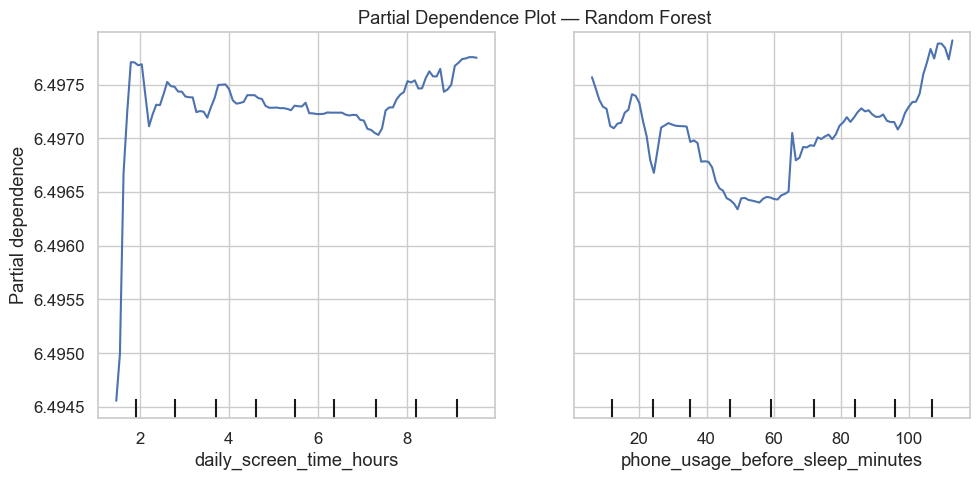

Le PDP montre l'effet marginal de chaque variable sur la prédiction, toutes autres variables fixées à leur moyenne.


In [14]:
# Partial Dependence Plot (PDP) — effet de daily_screen_time_hours sur sleep_duration_hours
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(10, 5))
PartialDependenceDisplay.from_estimator(
    rf,
    X_train,
    features=['daily_screen_time_hours', 'phone_usage_before_sleep_minutes'],
    ax=ax
)
ax.set_title('Partial Dependence Plot — Random Forest')
plt.tight_layout()
plt.show()
print('Le PDP montre l\'effet marginal de chaque variable sur la prédiction, toutes autres variables fixées à leur moyenne.')